In [1]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 

Text(0, 0.5, 'Y Dataset')

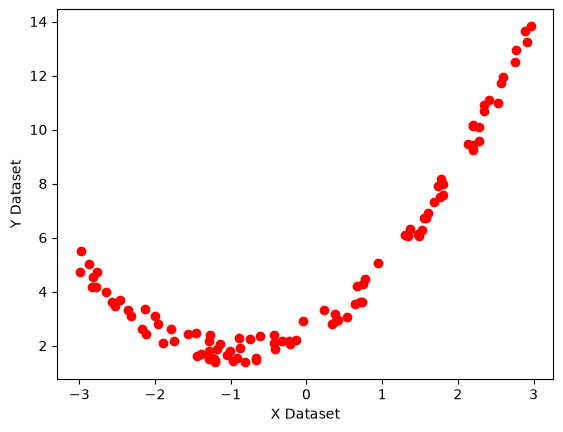

In [2]:
# My train data
X = 6 * np.random.rand(100,1) -3
y = 0.8 * X**2 + 1.5*X + 2 + np.random.rand(100,1)
plt.scatter(X,y,color="r")
plt.xlabel("X Dataset")
plt.ylabel("Y Dataset")

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)
print(X_train.shape, X_test.shape)

(80, 1) (20, 1)


In [4]:
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [5]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.52]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[4.85]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[15.33]


In [6]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.607442949555937


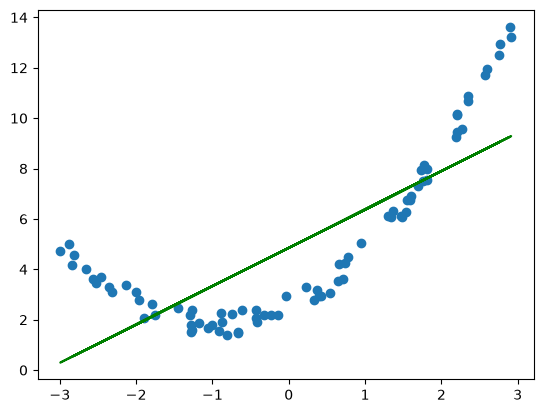

In [7]:
plt.plot(X_train,regression_1.predict(X_train),color="g")
plt.scatter(X_train,y_train)

In [8]:
# Lets apply polinomial
from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [10]:
X_train_poly

array([[ 1.00000000e+00, -2.87712347e+00,  8.27783944e+00],
       [ 1.00000000e+00, -6.67319987e-01,  4.45315965e-01],
       [ 1.00000000e+00,  4.22894621e-01,  1.78839861e-01],
       [ 1.00000000e+00,  1.55053611e+00,  2.40416223e+00],
       [ 1.00000000e+00, -8.79715331e-01,  7.73899063e-01],
       [ 1.00000000e+00, -2.65193922e+00,  7.03278164e+00],
       [ 1.00000000e+00, -1.28332124e+00,  1.64691341e+00],
       [ 1.00000000e+00, -2.81770890e+00,  7.93948347e+00],
       [ 1.00000000e+00, -1.01190376e+00,  1.02394923e+00],
       [ 1.00000000e+00, -2.00339865e+00,  4.01360617e+00],
       [ 1.00000000e+00, -1.89247235e+00,  3.58145159e+00],
       [ 1.00000000e+00,  2.34762465e+00,  5.51134150e+00],
       [ 1.00000000e+00, -2.99381236e+00,  8.96291242e+00],
       [ 1.00000000e+00,  6.62109517e-01,  4.38389012e-01],
       [ 1.00000000e+00, -1.28750873e+00,  1.65767874e+00],
       [ 1.00000000e+00, -7.46236198e-01,  5.56868463e-01],
       [ 1.00000000e+00,  2.77199829e+00

In [11]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score= r2_score(y_test,y_pred)
score

0.992723632343596

In [12]:
regression.coef_

array([[0.        , 1.51572302, 0.78509505]])

In [13]:
print(regression.intercept_)

[2.54392833]


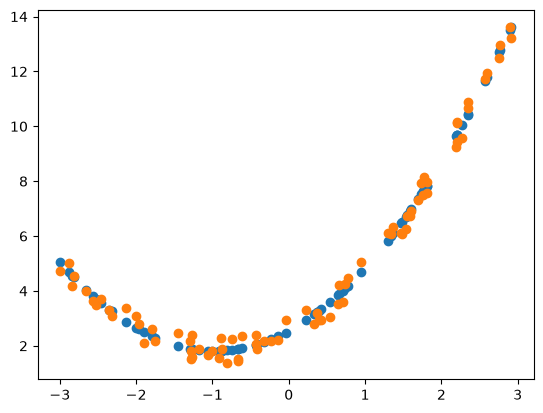

In [14]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [15]:
from sklearn.pipeline import Pipeline

In [16]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

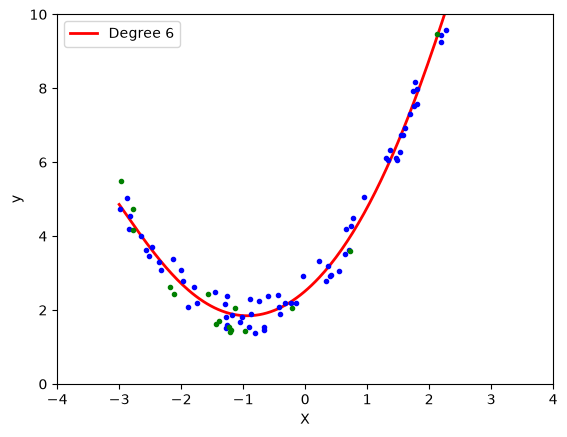

In [17]:
poly_regression(6)